<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 2</h3>
    <h3>Ejercicio 2</h3>
        <p>Docente: Rodrigo Del Rosso<p>
        <p>Asistentes: Sebastián Calcagno y Braian Drago<p>
</div>

Metodología de Box-Jenkinks

API no oficial de Google Trends. Para mantener siempre los mismos datos, en este ejercicio no se uso la api pero dejo la documentacion para que puedan obtener mayor meterial

 https://pypi.org/project/pytrends/

Fuente de los datos usados=
https://trends.google.com/trends/explore?date=today%203-m&geo=AR&q=cataratas&hl=es <br> Google Trends ofrece una variedad de datos y herramientas utiles para analizar la popularidad de términos de busqueda a lo largo del tiempo.



En este ejercicio nos vamos a guiar por la metodologia de Box-Jenkins consta de cuatro pasos principales: identificacion, estimacion , diagnostico y pronostico. A continuacion van a ver los diferentes pasos a seguir con sus respectivos ejemplos

In [ ]:
# Igual que el ejercicio 1, instalamos estas versiones para poder correr las librerias.
# Esto es principalmente para ejecutar "pmdarima" en este colab.

# !pip install pmdarima
!pip install numpy==1.26.4 pandas==2.2.2 statsmodels==0.14.4 pmdarima==2.0.4  # Primero
!pip install scipy==1.13.1  # Segundo

In [ ]:
from pmdarima import auto_arima

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.graphics.tsaplots as sgt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima_model import ARMA
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
from statsmodels.tsa.stattools import acf
from scipy.stats import chi2

In [ ]:
def Augmented_Dickey_Fuller_Test_func(series , column_name):
  print (f'Resultados de la prueba de Dickey-Fuller para columna: {column_name}')
  dftest = adfuller(series, autolag='AIC')
  dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','No Lags Used','Number of Observations Used'])
  for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
  print (dfoutput)
  if dftest[1] <= 0.05:
    print("Conclusion:====>")
    print("Rechazar la hipótesis nula")
    print("Los datos son estacionarios.")
  else:
    print("Conclusion:====>")
    print("No rechazar la hipótesis nula")
    print("Los datos no son estacionarios.")

In [ ]:
url='https://raw.githubusercontent.com/sebcalcagno/AnalisisSeriesTemporales/main/multiTimelineCataratas.csv'
dataoriginal = pd.read_csv(url)

<title>Paso 1</title>

Graficar los datos, identificar patrones y/o comportamientos inusuales. Una aproximacion visual permite identificar varias caracteristicas de las series, si bien no es determinante siempre es necesario saber como son nuestras bases a trabajar

In [ ]:
dataoriginal.head()

,Dia,Cataratas
0,3/4/2024,61
1,3/5/2024,55
2,3/6/2024,55
3,3/7/2024,71
4,3/8/2024,46


In [ ]:
dataoriginal['Dia'] = pd.to_datetime(dataoriginal['Dia'])
dataoriginal.index = dataoriginal['Dia']
del dataoriginal['Dia']

In [ ]:
dataoriginal.head()

,Cataratas
Dia,
2024-03-04,61
2024-03-05,55
2024-03-06,55
2024-03-07,71
2024-03-08,46


In [ ]:
dataoriginal=dataoriginal.asfreq('d')
dataoriginal.head()

,Cataratas
Dia,
2024-03-04,61
2024-03-05,55
2024-03-06,55
2024-03-07,71
2024-03-08,46


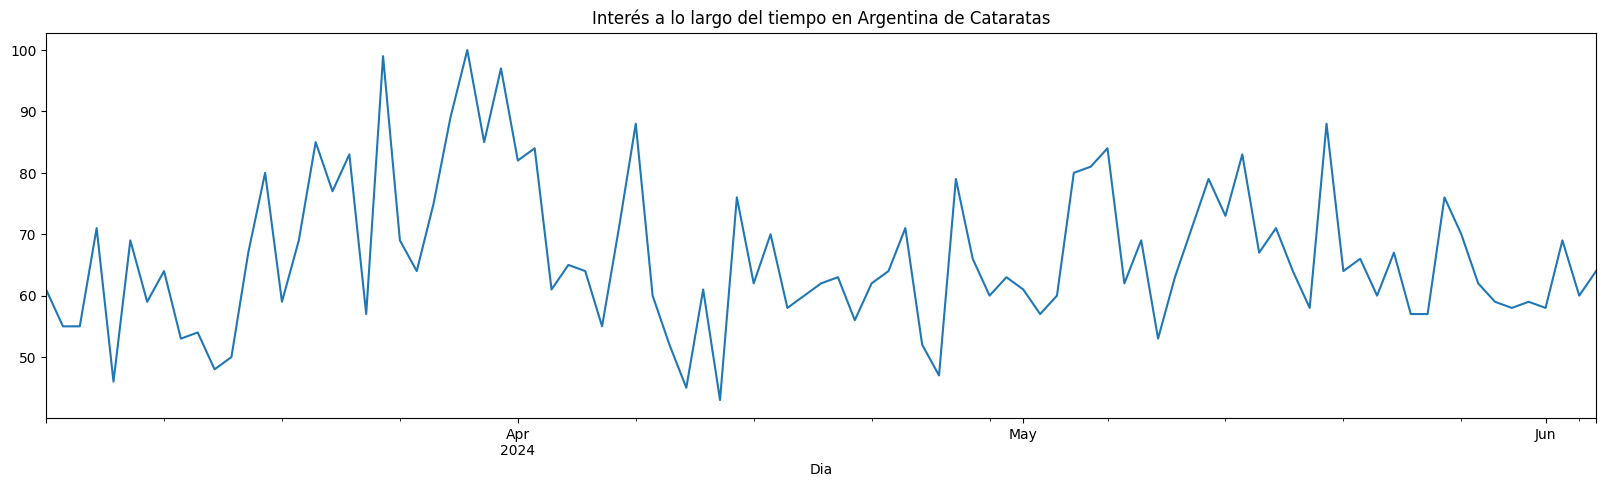

In [ ]:
dataoriginal.Cataratas.plot(figsize=(20,5), title = "Interés a lo largo del tiempo en Argentina de Cataratas")
plt.show()

<title>Paso 2</title>

Si es necesario utilizar transformacion de Box-Cox para estabilizar la varianza. Aquí se propone una transformación de los datos a fin de mejorar la homocedasticidad. Estas transformaciones se usan para estabilizar la varianza y produce que las desviaciones alrededor del modelo sean mas normalmente distribuidas

In [ ]:
#cargar los paquetes necesarios
from scipy.stats import jarque_bera, shapiro, boxcox, probplot

In [ ]:
# realizar la transformación de Box-Cox en datos originales
transform_data, best_lambda = boxcox (dataoriginal.Cataratas)

In [ ]:
print(f" El lambda óptima aproximado es =  {best_lambda}")

 El lambda óptima aproximado es =  -0.44831880714163186


In [ ]:
print(f" El array resultante luego de la transformacion de box-cox es =  {transform_data}")

 El array resultante luego de la transformacion de box-cox es =  [1.87735928 1.8605777  1.8605777  1.9005972  1.82971888 1.89634326
 1.872041   1.88488005 1.85438244 1.85752161 1.83729445 1.84442617
 1.89190688 1.91778776 1.872041   1.89634326 1.92617404 1.91238221
 1.92290744 1.866455   1.94628474 1.89634326 1.88488005 1.908606
 1.93238493 1.94756272 1.92617404 1.94367182 1.92123106 1.92455482
 1.87735928 1.88727445 1.88488005 1.8605777  1.9005972  1.93087062
 1.87473223 1.85115629 1.82574969 1.87735928 1.81741443 1.9105121
 1.87992468 1.89849223 1.86928287 1.87473223 1.87992468 1.88243085
 1.86355435 1.87992468 1.88488005 1.9005972  1.85115629 1.83356503
 1.91601899 1.88961608 1.87473223 1.88243085 1.87735928 1.866455
 1.87473223 1.91778776 1.9195248  1.92455482 1.87992468 1.89634326
 1.85438244 1.88243085 1.9005972  1.91601899 1.90468106 1.92290744
 1.89190688 1.9005972  1.88488005 1.86928287 1.93087062 1.88488005
 1.88961608 1.87473223 1.89190688 1.866455   1.866455   1.9105121
 1.

In [ ]:
# Para datos con transformacion de Box Cox
jarque_bera(transform_data)

SignificanceResult(statistic=0.03295869920803751, pvalue=0.9836556920604895)

Con un valor p de 0.9837 no se rechaza la hip nula de normalidad. Esto significa que luego de la transformacion de Box-Cox los datos transformados pueden considerarse normalmente distribuidos.

In [ ]:
# Para datos originales
jarque_bera(dataoriginal.Cataratas)

SignificanceResult(statistic=7.471959995304841, pvalue=0.023849786877241718)

Con un valor p de 0.02385 se rechaza la hipotesis nula de normalidad para los datos originales. Esto indica que los datos no siguen una distribucion normal.

# Usamos algoritmos automatizados
- Usamos Auto arima para encontrar el mejor modelo de series de tiempo.

In [ ]:
len(dataoriginal)

93

In [ ]:
X = dataoriginal[['Cataratas' ]]
train, test = X[0:-6], X[-6:]
X.head()

,Cataratas
Dia,
2024-03-04,61
2024-03-05,55
2024-03-06,55
2024-03-07,71
2024-03-08,46


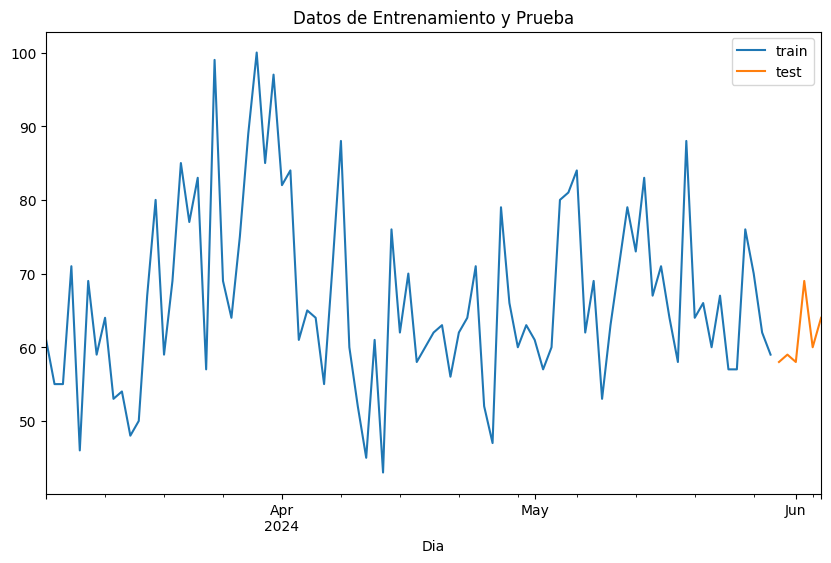

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
train.plot(ax=ax)
test.plot(ax=ax)
plt.title("Datos de Entrenamiento y Prueba")
plt.legend(['train', 'test'])
plt.show()

In [ ]:
train.head()

,Cataratas
Dia,
2024-03-04,61
2024-03-05,55
2024-03-06,55
2024-03-07,71
2024-03-08,46


In [ ]:
test

,Cataratas
Dia,
2024-05-30,58
2024-05-31,59
2024-06-01,58
2024-06-02,69
2024-06-03,60
2024-06-04,64


In [ ]:
stepwise_model1 = auto_arima(train.Cataratas,max_order= None ,
max_p=7, max_q=7, maxiter= 5000, trace =True ,n_jobs=-1,alpha=0.05)
   # trace=True,suppress_warnings=True)
stepwise_model1.summary()

/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will 

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=680.569, Time=0.20 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=687.311, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=679.300, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=682.694, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=982.664, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=677.120, Time=0.08 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=679.115, Time=0.17 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=677.260, Time=0.29 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=681.110, Time=0.16 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.05 sec

Best model:  ARIMA(2,0,0)(0,0,0)[0] intercept
Total fit time: 1.196 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   87
Model:               SARIMAX(2, 0, 0)   Log Likelihood                -334.560
Date:                Fri, 24 Jul 2026   AIC                            677.120
Time:                        00:28:42   BIC                            686.984
Sample:                    03-04-2024   HQIC                           681.092
                         - 05-29-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     35.2502      7.810      4.514      0.000      19.944      50.557
ar.L1          0.2561      0.104      2.458      0.014       0.052       0.460
ar.L2          0.2139      0.101      2.120      0.034       0.016       0.412
sigma2       127.8377     23.560      5.426      0.000      81.662     174.014
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 5.37
Prob(Q):                              0.96   Prob(JB):                         0.07
Heteroskedasticity (H):               0.51   Skew:                             0.60
Prob(H) (two-sided):                  0.07   Kurtosis:                         2.75
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

# Por otro lado, se puede seleccionar el modelo de forma no automatica

3 . Si es necesario, diferenciamos los datos hasta que sean estacionarios. Usar el test de raiz unitaria para comprobar lo dicho.

El test de Dickey Fuller, pone a prueba la estacionariedad de la serie. Es decir, que la raiz sea o no estacionaria. La presencia de estacionariedad es cuando las raices son en modulo mayores que uno.
Regla de decision =

De los modelos AR(p)
- Si el "p-value" es menor a 0.05 --> Rechazo H0
- Si el "p-value" es mayor a 0.05 --> No Rechazo H0

Donde =

<h5>H0 --> no estacionario</h5>
<h5>H1  --> Estacionario</h5>

Tengan en cuenta que esto es solo una introduccion del test

In [ ]:
Augmented_Dickey_Fuller_Test_func(train['Cataratas'],'Cataratas')

Resultados de la prueba de Dickey-Fuller para columna: Cataratas
Test Statistic                 -4.231021
p-value                         0.000584
No Lags Used                    1.000000
Number of Observations Used    85.000000
Critical Value (1%)            -3.509736
Critical Value (5%)            -2.896195
Critical Value (10%)           -2.585258
dtype: float64
Conclusion:====>
Rechazar la hipótesis nula
Los datos son estacionarios.


4. Graficamos las funciones de autocorrelacion y autocorrelacion parcial para determinar los posibles modelos.

La funcion de autocorrelacion nos da la pauta, cuando estamos trabajando con un modelo AR(p) si la serie es o no es estacionaria.
Por otro lado, la funcion de autocorrelacion parcial, nos indica el orden del modelo Autoregresivo.

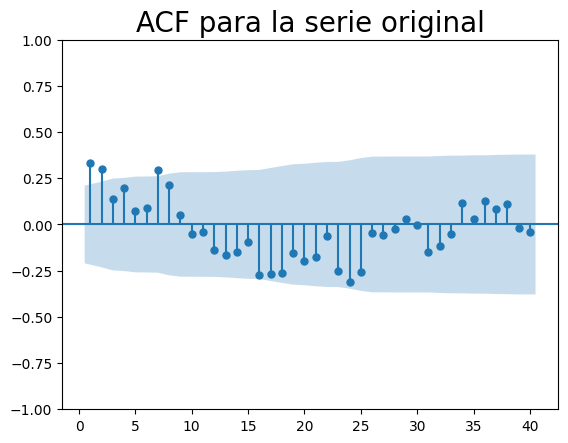

In [ ]:
sgt.plot_acf(train.Cataratas, zero = False, lags = 40)
plt.title("ACF para la serie original", size = 20)
plt.show()

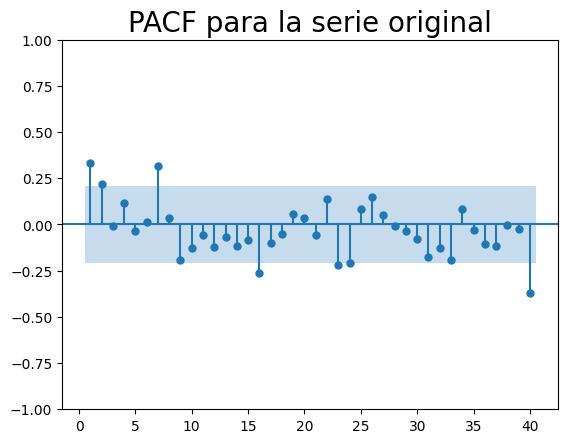

In [ ]:
sgt.plot_pacf(train.Cataratas, lags = 40, alpha = 0.05, zero = False, method = ('ols'))
plt.title("PACF para la serie original", size = 20)
plt.show()

5. Realizamos una preselección del modelo, y luego verificamos el mejor modelo a través de los criterios de informacion.

In [ ]:
# Modelo 1

import statsmodels.api as sm
modeloAR2 = sm.tsa.arima.ARIMA(train.Cataratas, order=(2,0,0))
resultAR2 = modeloAR2.fit()

resultAR2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              Cataratas   No. Observations:                   87
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -334.560
Date:                Fri, 24 Jul 2026   AIC                            677.119
Time:                        00:28:43   BIC                            686.983
Sample:                    03-04-2024   HQIC                           681.091
                         - 05-29-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         66.5023      2.582     25.758      0.000      61.442      71.563
ar.L1          0.2580      0.104      2.476      0.013       0.054       0.462
ar.L2          0.2158      0.101      2.139      0.032       0.018       0.414
sigma2       127.8345     23.558      5.426      0.000      81.661     174.008
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 5.37
Prob(Q):                              0.97   Prob(JB):                         0.07
Heteroskedasticity (H):               0.51   Skew:                             0.60
Prob(H) (two-sided):                  0.07   Kurtosis:                         2.75
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# Modelo 2

modeloAR2_16 = sm.tsa.arima.ARIMA(train.Cataratas, order=((1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1),0,0))
resultAR2_16 = modeloAR2_16.fit()

resultAR2_16.summary()

# modeloAR2_16 = sm.tsa.arima.ARIMA(train.Cataratas, order=((1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1),0,(1,0,1)))

# Modelo 1 -->AIC	677.119
# Modelo 2 ---> AIC= 667.534
# Libreria pdmarima "autoarima"

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  SARIMAX Results                                  
===================================================================================
Dep. Variable:                   Cataratas   No. Observations:                   87
Model:             ARIMA([1, 7, 16], 0, 0)   Log Likelihood                -328.767
Date:                     Fri, 24 Jul 2026   AIC                            667.534
Time:                             00:28:44   BIC                            679.863
Sample:                         03-04-2024   HQIC                           672.498
                              - 05-29-2024                                         
Covariance Type:                       opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         66.8195      1.683     39.695      0.000      63.520      70.119
ar.L1          0.2782      0.090      3.108      0.002       0.103       0.454
ar.L7          0.2854      0.109      2.611      0.009       0.071       0.500
ar.L16        -0.2828      0.079     -3.588      0.000      -0.437      -0.128
sigma2       109.1896     21.149      5.163      0.000      67.738     150.641
===================================================================================
Ljung-Box (L1) (Q):                   1.39   Jarque-Bera (JB):                 2.75
Prob(Q):                              0.24   Prob(JB):                         0.25
Heteroskedasticity (H):               0.48   Skew:                             0.32
Prob(H) (two-sided):                  0.06   Kurtosis:                         2.41
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Paso 6. Analizamos los residuos del modelo

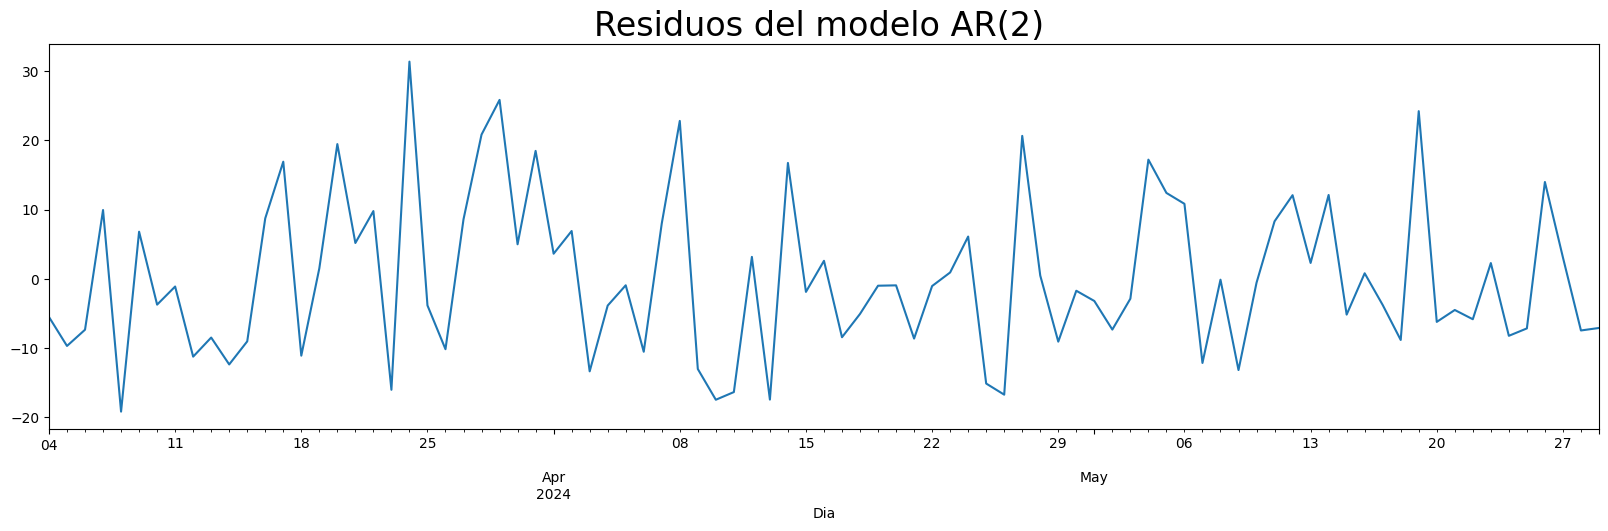

In [ ]:
resultAR2.resid.plot(figsize=(20,5))
plt.title("Residuos del modelo AR(2) ",size=24)
plt.show()

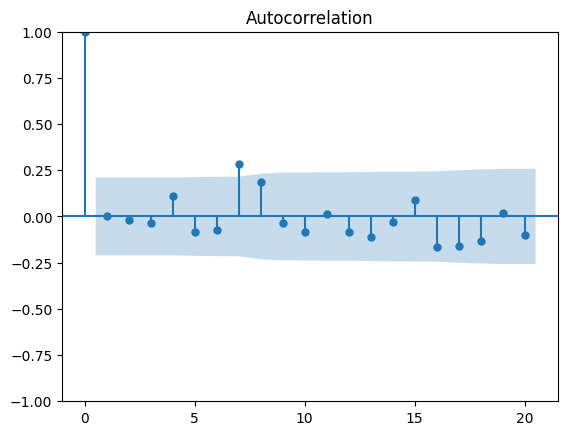

In [ ]:
plot_acf(resultAR2.resid);

In [ ]:
import statsmodels.api as sm

In [ ]:
Incorr_residuos_modelo=sm.stats.acorr_ljungbox(resultAR2.resid, lags=30)

In [ ]:
Incorr_residuos_modelo

,lb_stat,lb_pvalue
1,0.001707,0.967046
2,0.036681,0.981827
3,0.165234,0.982996
4,1.276426,0.865362
5,1.975602,0.852511
6,2.504088,0.868010
7,10.265373,0.174027
8,13.760458,0.088227
9,13.880230,0.126650
10,14.596281,0.147489


Text(0, 0.5, 'P-valores ')

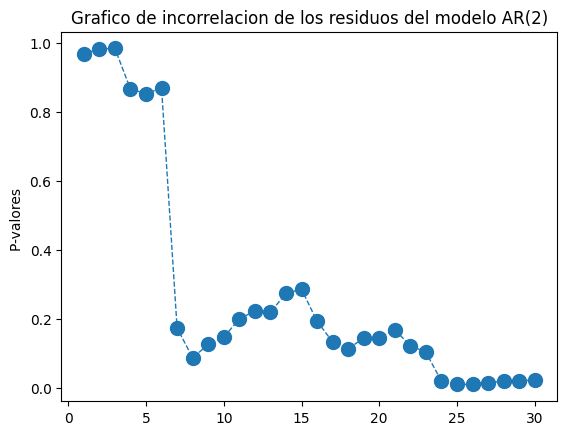

In [ ]:
plt.plot(Incorr_residuos_modelo.lb_pvalue, marker='o', markersize=10, linestyle='--', linewidth=1)
plt.title("Grafico de incorrelacion de los residuos del modelo AR(2)")
plt.ylabel("P-valores ")

Los residuos del modelo AR(2) no son completamente incorrelados. Osea hay estructura restante en los residuos especialmente a partir del lag 7. Esto viola el supuesto de ruido blanco que es deseable para un buen ajuste de modelo.

In [ ]:
# Test Box-Pierce
lags = 10

acf_values = acf(resultAR2.resid, nlags=lags, fft=False)

In [ ]:
# Calculamos el estadistico de prueba Q de Box-Pierce
n = len(resultAR2.resid)
Q = n * np.sum(np.square(acf_values[1:lags+1]))
p_value = 1 - chi2.cdf(Q, df=lags)

In [ ]:
print(f'Estadística de prueba (Q): {Q:.4f}')
print(f'Valor p: {p_value:.4f}')
alpha = 0.05
if p_value < alpha:
    print("Se rechaza la hipótesis nula: hay autocorrelación significativa en los residuos.")
else:
    print("No se rechaza la hipótesis nula: no hay autocorrelación significativa en los residuos.")

Estadística de prueba (Q): 13.1211
Valor p: 0.2170
No se rechaza la hipótesis nula: no hay autocorrelación significativa en los residuos.


Paso 7. ¿ los residuos se comportan como ruido blanco ? Si es afirmativo ---> Prediccion

In [ ]:
# Pasamos a la prediccion
forecastAR2 = resultAR2.get_forecast(steps=6)

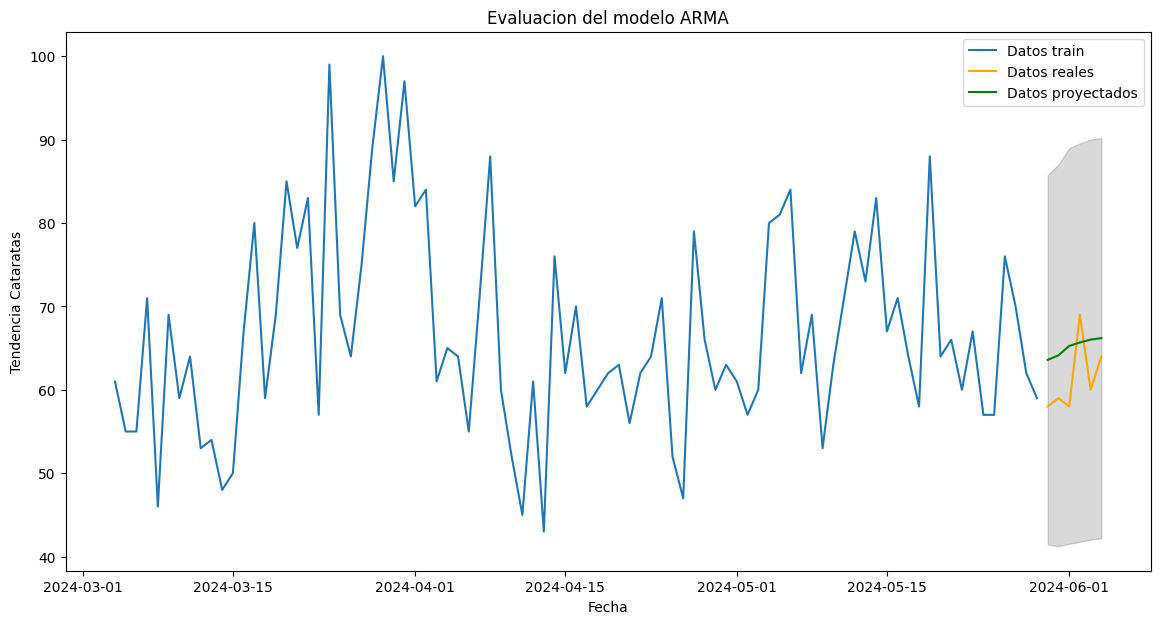

RMSE: 5.205103292405983


In [ ]:
test_forecast_series = pd.Series(forecastAR2.predicted_mean, index=test.index)

mse = mean_squared_error(test['Cataratas'], test_forecast_series)
rmse = mse**0.5

plt.figure(figsize=(14,7))
plt.plot(train['Cataratas'], label='Datos train')
plt.plot(test['Cataratas'], label='Datos reales', color='orange')
plt.plot(test_forecast_series, label='Datos proyectados', color='green')
plt.fill_between(test.index,
                 forecastAR2.conf_int().iloc[:, 0],
                 forecastAR2.conf_int().iloc[:, 1],
                 color='k', alpha=.15)
plt.title('Evaluacion del modelo ARMA')
plt.xlabel('Fecha')
plt.ylabel('Tendencia Cataratas')
plt.legend()
plt.show()

print('RMSE:', rmse)

Repito pasos 6 y 7 para el modelo 2 ( modelo con mejor criterio de informacion )

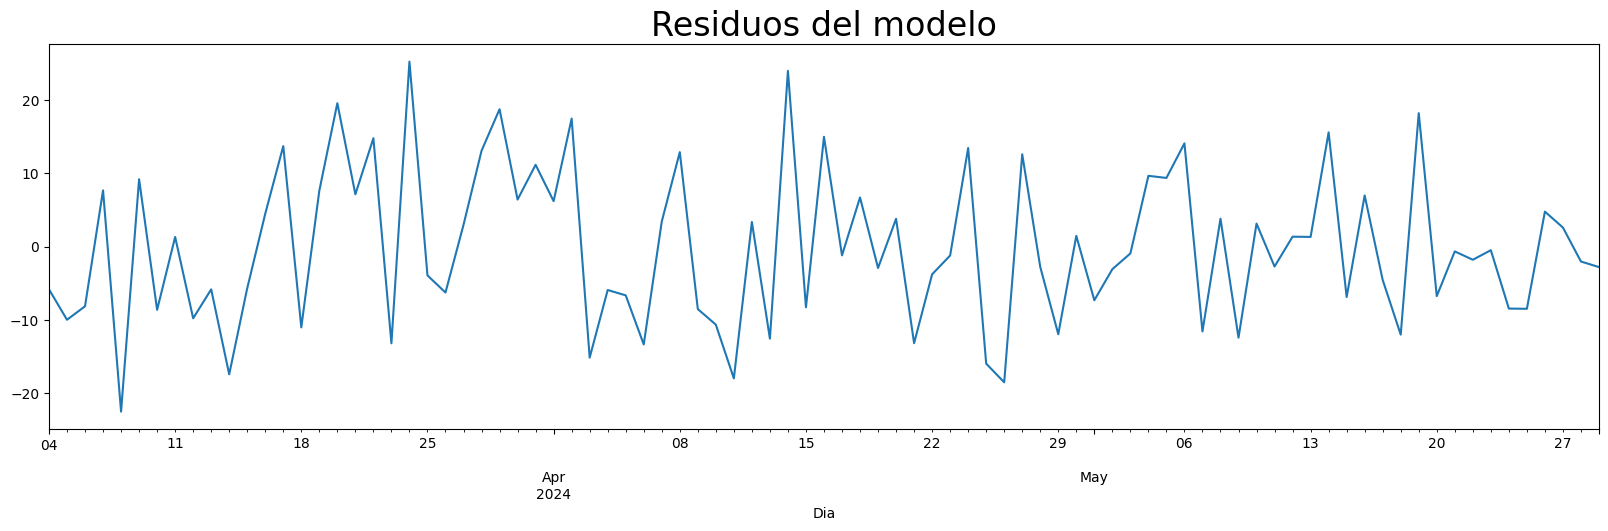

In [ ]:
resultAR2_16.resid.plot(figsize=(20,5))
plt.title("Residuos del modelo",size=24)
plt.show()


In [ ]:
# defino diferentes variables para realizar analisis manual de la funcion de autocorrelaion

T = resultAR2_16.resid.shape[0]  # número de datos
M = 12   # máximo número de rezagos que elijo
rezagos = np.arange(1, M+1)
alpha = 0.05  # significancia de los test

print(rezagos)

[ 1  2  3  4  5  6  7  8  9 10 11 12]


In [ ]:
rho = sm.tsa.acf(resultAR2_16.resid, fft=True, nlags=M)[1:]
rho
# Aqui vemos si los numeros son grandes o pequeños.
# Si son grandes es evidencia en contra de que los rezagos son ruido blanco ( si son pequeños es una evidencia, a favor del ruido blanco).

array([-0.12737954,  0.18849021, -0.06723384,  0.14097698, -0.08855818,
        0.01259359, -0.02486126,  0.10583966, -0.02377893, -0.02145569,
       -0.01666622, -0.07889126])

In [ ]:
resumen2 = pd.DataFrame({'AC':rho}, index=rezagos)
resumen2.index.name = 'Rezagos'

resumen2.round(4)

,AC
Rezagos,
1,-0.1274
2,0.1885
3,-0.0672
4,0.1410
5,-0.0886
6,0.0126
7,-0.0249
8,0.1058
9,-0.0238


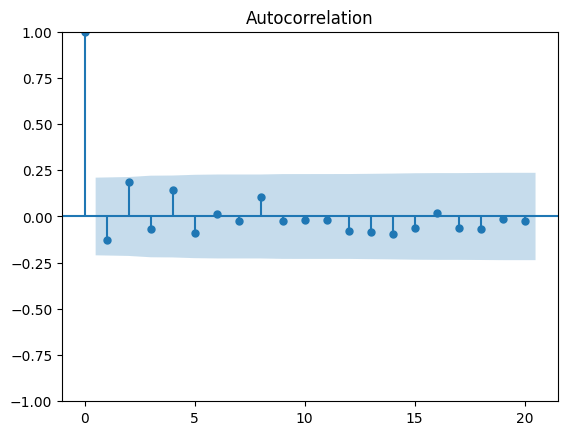

In [ ]:
plot_acf(resultAR2_16.resid);

In [ ]:
Incorr_residuos_modelo=sm.stats.acorr_ljungbox(resultAR2_16.resid, lags=30)

In [ ]:
Incorr_residuos_modelo

,lb_stat,lb_pvalue
1,1.460865,0.226792
2,4.697308,0.095498
3,5.113991,0.163638
4,6.968067,0.137585
5,7.708614,0.173042
6,7.723775,0.259047
7,7.783598,0.352062
8,8.881539,0.352388
9,8.937670,0.443048
10,8.983961,0.533626


Text(0, 0.5, 'P-valores ')

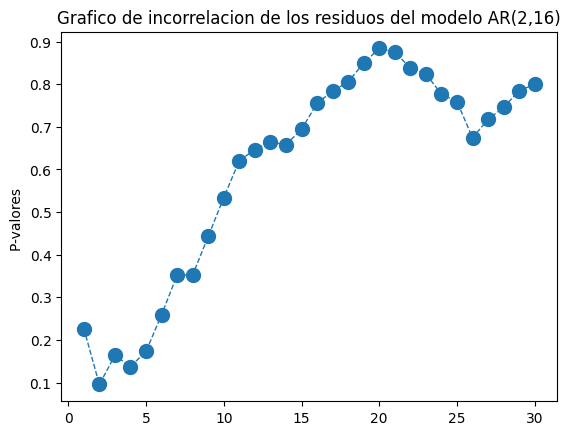

In [ ]:
plt.plot(Incorr_residuos_modelo.lb_pvalue, marker='o', markersize=10, linestyle='--', linewidth=1)
plt.title("Grafico de incorrelacion de los residuos del modelo AR(2,16)")
plt.ylabel("P-valores ")

In [ ]:
# Test Box-Pierce

lags = 10
acf_values = acf(resultAR2_16.resid, nlags=lags, fft=False)

# Calcular la estadística de prueba Q de Box-Pierce
n = len(resultAR2_16.resid)
Q = n * np.sum(np.square(acf_values[1:lags+1]))
p_value = 1 - chi2.cdf(Q, df=lags)



In [ ]:
print(f'Estadística de prueba (Q): {Q:.4f}')
print(f'Valor p: {p_value:.4f}')
alpha = 0.05
if p_value < alpha:
    print("Se rechaza la hipótesis nula: hay autocorrelación significativa en los residuos.")
else:
    print("No se rechaza la hipótesis nula: no hay autocorrelación significativa en los residuos.")

Estadística de prueba (Q): 8.4387
Valor p: 0.5861
No se rechaza la hipótesis nula: no hay autocorrelación significativa en los residuos.


Comportamiento deseable de los residuos del modelo:

- Ruido blanco (el modelo captura la estructura)
- Media aprox a cero ( ajuste correcto)
- varianza constante (predicciones estables)
- aprox normales (intervalos razonables)
- independiente (modelo bien especificaod)

# Pasamos a la proyeccion

In [ ]:
forecastAR2_16 = resultAR2_16.get_forecast(steps=6)

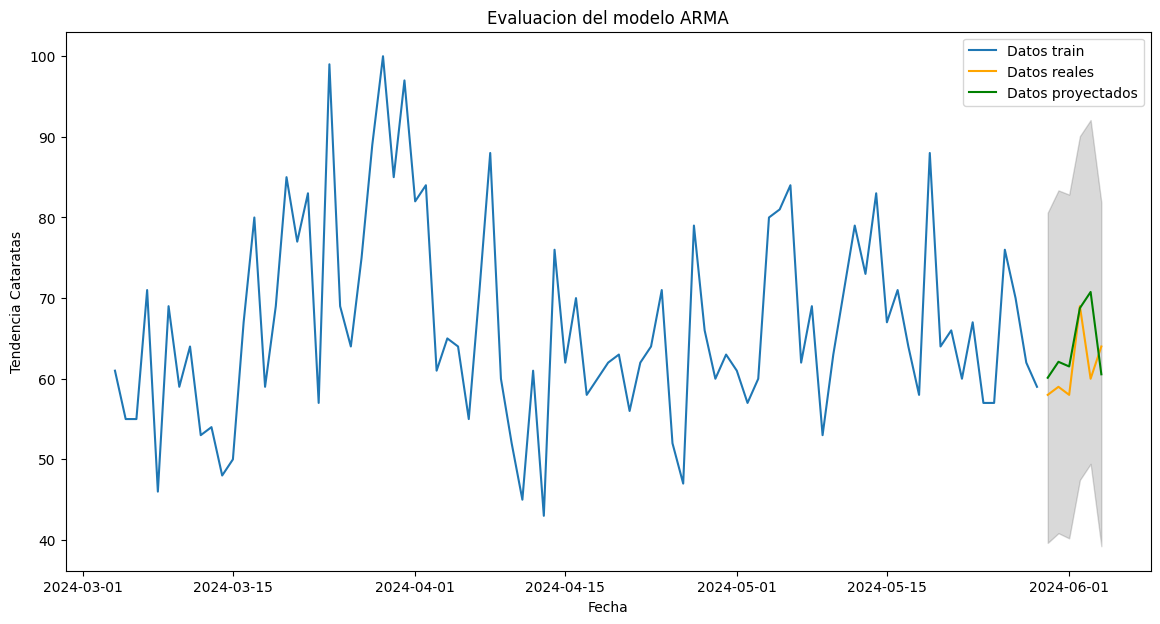

In [ ]:
test_forecast_series = pd.Series(forecastAR2_16.predicted_mean, index=test.index)


mse = mean_squared_error(test['Cataratas'], test_forecast_series)
rmse_2 = mse**0.5


plt.figure(figsize=(14,7))
plt.plot(train['Cataratas'], label='Datos train')
plt.plot(test['Cataratas'], label='Datos reales', color='orange')
plt.plot(test_forecast_series, label='Datos proyectados', color='green')
plt.fill_between(test.index,
                 forecastAR2_16.conf_int().iloc[:, 0],
                 forecastAR2_16.conf_int().iloc[:, 1],
                 color='k', alpha=.15)
plt.title('Evaluacion del modelo ARMA')
plt.xlabel('Fecha')
plt.ylabel('Tendencia Cataratas')
plt.legend()
plt.show()



In [ ]:
print('El RMSE del AR(2) es:', rmse)
print('El RMSE del segundo modelo es:', rmse_2)

El RMSE del AR(2) es: 5.205103292405983
El RMSE del segundo modelo es: 5.071102499065454


Recordamos que el RMSE mide el error promedio en las predicciones penalizando mas los errores grandes. Por lo tanto, segun esta metrica, el segundo modelo es mejor.

FIN DEL CODIGO